https://www.kaggle.com/c/bike-sharing-demand/data?select=train.csv

In [1]:
# 바이크 대여량 예측 모델

In [2]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import lightgbm as lgb
import seaborn as sns
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import mean_squared_log_error

# ✅ 한글 폰트 설정 (Windows: 맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

In [3]:
BSD_DF_train = pd.read_csv('./data/bike-sharing-demand/train.csv')
BSD_DF_train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [4]:
BSD_DF_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [5]:
BSD_DF_train.drop(columns=['datetime',]).corr()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
season,1.000000,0.029368,-0.008126,0.008879,0.258689,0.264744,0.190610,-0.147121,0.096758,0.164011,0.163439
holiday,0.029368,1.000000,-0.250491,-0.007074,0.000295,-0.005215,0.001929,0.008409,0.043799,-0.020956,-0.005393
workingday,-0.008126,-0.250491,1.000000,0.033772,0.029966,0.024660,-0.010880,0.013373,-0.319111,0.119460,0.011594
weather,0.008879,-0.007074,0.033772,1.000000,-0.055035,-0.055376,0.406244,0.007261,-0.135918,-0.109340,-0.128655
temp,0.258689,0.000295,0.029966,-0.055035,1.000000,0.984948,-0.064949,-0.017852,0.467097,0.318571,0.394454
atemp,0.264744,-0.005215,0.024660,-0.055376,0.984948,1.000000,-0.043536,-0.057473,0.462067,0.314635,0.389784
humidity,0.190610,0.001929,-0.010880,0.406244,-0.064949,-0.043536,1.000000,-0.318607,-0.348187,-0.265458,-0.317371
windspeed,-0.147121,0.008409,0.013373,0.007261,-0.017852,-0.057473,-0.318607,1.000000,0.092276,0.091052,0.101369
casual,0.096758,0.043799,-0.319111,-0.135918,0.467097,0.462067,-0.348187,0.092276,1.000000,0.497250,0.690414
registered,0.164011,-0.020956,0.119460,-0.109340,0.318571,0.314635,-0.265458,0.091052,0.497250,1.000000,0.970948


In [6]:
BSD_DF_train['datetime'] = pd.to_datetime(BSD_DF_train['datetime'])

BSD_DF_train['year'] = BSD_DF_train['datetime'].dt.year
BSD_DF_train['month'] = BSD_DF_train['datetime'].dt.month
BSD_DF_train['day'] = BSD_DF_train['datetime'].dt.day
BSD_DF_train['hour'] = BSD_DF_train['datetime'].dt.hour
BSD_DF_train['weekday'] = BSD_DF_train['datetime'].dt.weekday


In [7]:
BSD_DF_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  weekday     10886 non-

In [8]:
BSD_DF_train = BSD_DF_train.drop(columns=['datetime', 'casual', 'registered'])
BSD_DF_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      10886 non-null  int64  
 1   holiday     10886 non-null  int64  
 2   workingday  10886 non-null  int64  
 3   weather     10886 non-null  int64  
 4   temp        10886 non-null  float64
 5   atemp       10886 non-null  float64
 6   humidity    10886 non-null  int64  
 7   windspeed   10886 non-null  float64
 8   count       10886 non-null  int64  
 9   year        10886 non-null  int32  
 10  month       10886 non-null  int32  
 11  day         10886 non-null  int32  
 12  hour        10886 non-null  int32  
 13  weekday     10886 non-null  int32  
dtypes: float64(3), int32(5), int64(6)
memory usage: 978.2 KB


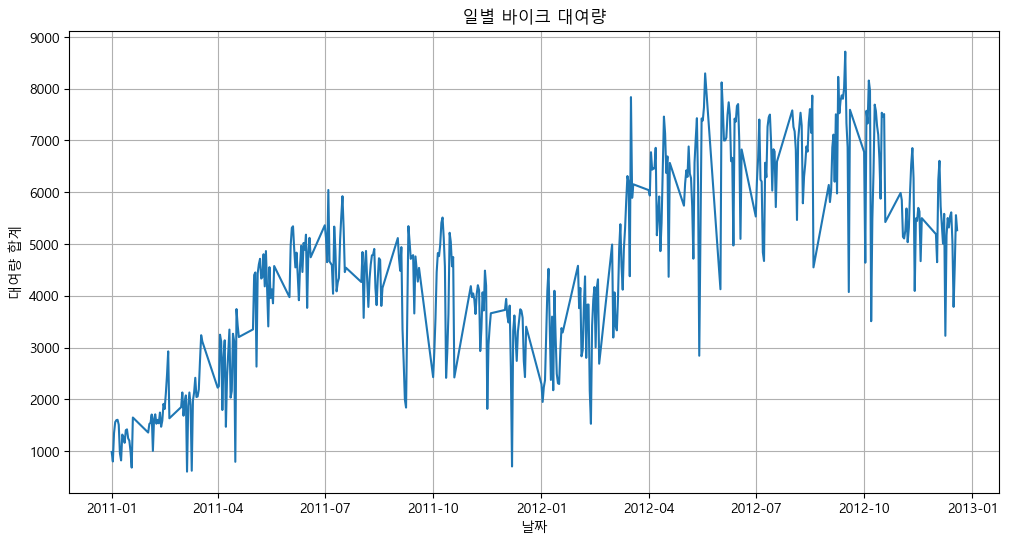

In [9]:
import matplotlib.pyplot as plt

# 'day' 기준으로 대여량 합계 집계
daily_rentals = BSD_DF_train.groupby(['year', 'month', 'day'])['count'].sum()

# 인덱스를 datetime으로 변환 (year, month, day 합쳐서)
daily_rentals.index = pd.to_datetime(daily_rentals.index.map(lambda x: f"{x[0]}-{x[1]}-{x[2]}"))

# 그래프 그리기
plt.figure(figsize=(12, 6))
plt.plot(daily_rentals.index, daily_rentals.values)
plt.title('일별 바이크 대여량')
plt.xlabel('날짜')
plt.ylabel('대여량 합계')
plt.grid(True)
plt.show()


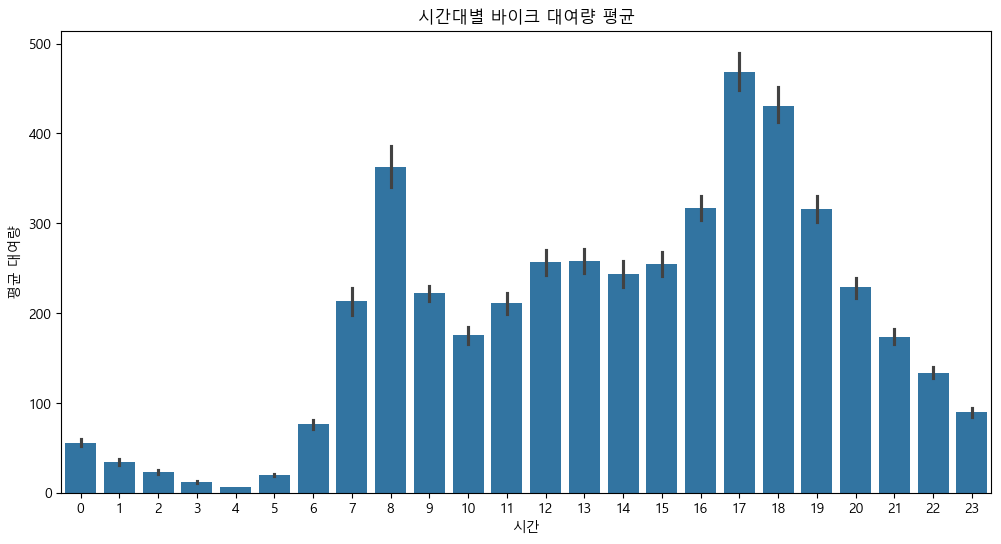

In [10]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='hour', y='count', data=BSD_DF_train)
plt.title('시간대별 바이크 대여량 평균')
plt.xlabel('시간')
plt.ylabel('평균 대여량')
plt.show()


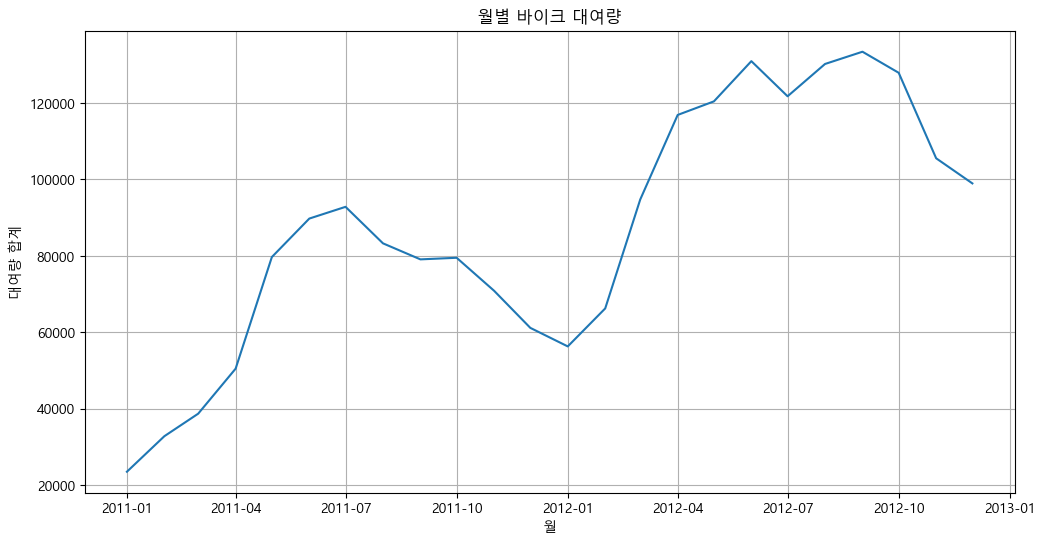

In [11]:
monthly_rentals = BSD_DF_train.groupby(['year', 'month'])['count'].sum()
monthly_rentals.index = pd.to_datetime(monthly_rentals.index.map(lambda x: f"{x[0]}-{x[1]}"))

plt.figure(figsize=(12, 6))
plt.plot(monthly_rentals.index, monthly_rentals.values)
plt.title('월별 바이크 대여량')
plt.xlabel('월')
plt.ylabel('대여량 합계')
plt.grid(True)
plt.show()


In [12]:
BSD_DF_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      10886 non-null  int64  
 1   holiday     10886 non-null  int64  
 2   workingday  10886 non-null  int64  
 3   weather     10886 non-null  int64  
 4   temp        10886 non-null  float64
 5   atemp       10886 non-null  float64
 6   humidity    10886 non-null  int64  
 7   windspeed   10886 non-null  float64
 8   count       10886 non-null  int64  
 9   year        10886 non-null  int32  
 10  month       10886 non-null  int32  
 11  day         10886 non-null  int32  
 12  hour        10886 non-null  int32  
 13  weekday     10886 non-null  int32  
dtypes: float64(3), int32(5), int64(6)
memory usage: 978.2 KB


In [13]:
BSD_DF_train[['temp', 'atemp', 'humidity', 'windspeed','count']].corr()

,temp,atemp,humidity,windspeed,count
temp,1.000000,0.984948,-0.064949,-0.017852,0.394454
atemp,0.984948,1.000000,-0.043536,-0.057473,0.389784
humidity,-0.064949,-0.043536,1.000000,-0.318607,-0.317371
windspeed,-0.017852,-0.057473,-0.318607,1.000000,0.101369
count,0.394454,0.389784,-0.317371,0.101369,1.000000


In [14]:
corr_matrix = BSD_DF_train.corr(numeric_only=True)  # 숫자형만 상관계수 계산
corr_matrix

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day,hour,weekday
season,1.000000,0.029368,-0.008126,0.008879,0.258689,0.264744,0.190610,-0.147121,0.163439,-0.004797,0.971524,0.001729,-0.006546,-0.010553
holiday,0.029368,1.000000,-0.250491,-0.007074,0.000295,-0.005215,0.001929,0.008409,-0.005393,0.012021,0.001731,-0.015877,-0.000354,-0.191832
workingday,-0.008126,-0.250491,1.000000,0.033772,0.029966,0.024660,-0.010880,0.013373,0.011594,-0.002482,-0.003394,0.009829,0.002780,-0.704267
weather,0.008879,-0.007074,0.033772,1.000000,-0.055035,-0.055376,0.406244,0.007261,-0.128655,-0.012548,0.012144,-0.007890,-0.022740,-0.047692
temp,0.258689,0.000295,0.029966,-0.055035,1.000000,0.984948,-0.064949,-0.017852,0.394454,0.061226,0.257589,0.015551,0.145430,-0.038466
atemp,0.264744,-0.005215,0.024660,-0.055376,0.984948,1.000000,-0.043536,-0.057473,0.389784,0.058540,0.264173,0.011866,0.140343,-0.040235
humidity,0.190610,0.001929,-0.010880,0.406244,-0.064949,-0.043536,1.000000,-0.318607,-0.317371,-0.078606,0.204537,-0.011335,-0.278011,-0.026507
windspeed,-0.147121,0.008409,0.013373,0.007261,-0.017852,-0.057473,-0.318607,1.000000,0.101369,-0.015221,-0.150192,0.036157,0.146631,-0.024804
count,0.163439,-0.005393,0.011594,-0.128655,0.394454,0.389784,-0.317371,0.101369,1.000000,0.260403,0.166862,0.019826,0.400601,-0.002283
year,-0.004797,0.012021,-0.002482,-0.012548,0.061226,0.058540,-0.078606,-0.015221,0.260403,1.000000,-0.004932,0.001800,-0.004234,-0.003785


In [15]:
BSD_DF_train = BSD_DF_train.drop(columns=['windspeed','season'])

In [16]:
# weather == 4 제거 (악천후) -샘플이 1개밖에 없어 이상치로 간주
BSD_DF_train = BSD_DF_train[BSD_DF_train['weather'] != 4]

In [17]:
# 데이터 분리

# 입력 변수 X (count 컬럼 제외)
X = BSD_DF_train.drop(columns=['count'])
# 타겟 변수 y
y = BSD_DF_train['count']

In [18]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10885 entries, 0 to 10885
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   holiday     10885 non-null  int64  
 1   workingday  10885 non-null  int64  
 2   weather     10885 non-null  int64  
 3   temp        10885 non-null  float64
 4   atemp       10885 non-null  float64
 5   humidity    10885 non-null  int64  
 6   year        10885 non-null  int32  
 7   month       10885 non-null  int32  
 8   day         10885 non-null  int32  
 9   hour        10885 non-null  int32  
 10  weekday     10885 non-null  int32  
dtypes: float64(2), int32(5), int64(4)
memory usage: 807.9 KB


In [19]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

In [20]:
# 모델 학습
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
# 예측
rf_pred = rf.predict(X_test)
# 평가
# MSE (음수로 반환되므로 부호 반전 필요)
neg_mse_scores = cross_val_score(
    rf, X, y,
    scoring='neg_mean_squared_error',
    cv=5
)
mse_scores = -neg_mse_scores
rmse_scores = np.sqrt(mse_scores)

# R² 점수
r2_scores = cross_val_score(
    rf, X, y,
    scoring='r2',
    cv=5
)

# 결과 출력
print("교차검증 결과 (5-fold):")
print(f"평균 MSE:  {mse_scores.mean():.4f}")
print(f"평균 RMSE: {rmse_scores.mean():.4f}")
print(f"평균 R²:   {r2_scores.mean():.4f}")

교차검증 결과 (5-fold):
평균 MSE:  5481.1711
평균 RMSE: 72.9212
평균 R²:   0.7075


       feature  importance
9         hour    0.602321
6         year    0.089006
3         temp    0.071879
7        month    0.060101
1   workingday    0.054847
10     weekday    0.035520
5     humidity    0.030359
4        atemp    0.028998
2      weather    0.013906
8          day    0.011036
0      holiday    0.002026


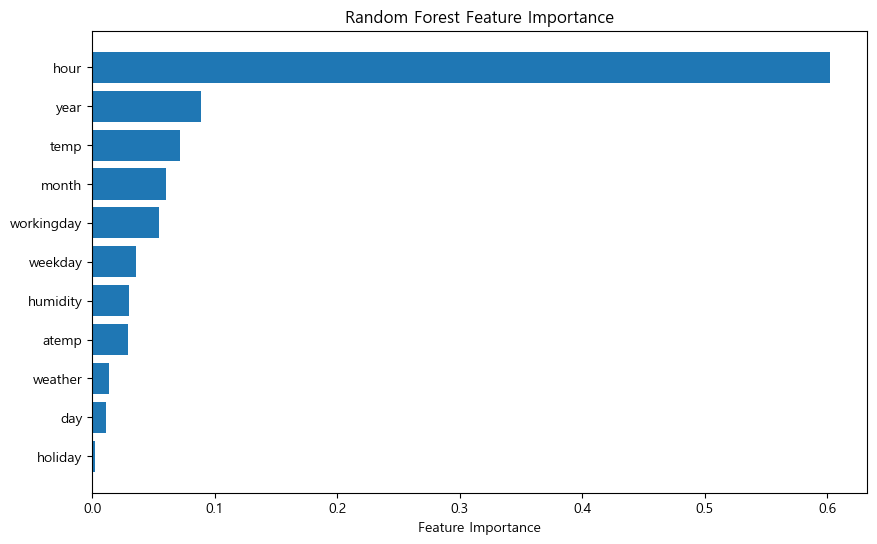

In [21]:
# 학습된 모델 rf가 있어야 합니다 (이미 학습한 상태)

# 1. 피처 중요도 추출
importances = rf.feature_importances_

# 2. 피처 이름 (X의 컬럼명)
feature_names = X.columns

# 3. 데이터프레임 생성 (정렬을 위해)
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# 4. 중요도 내림차순 정렬
feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False)

# 5. 출력
print(feat_imp_df)

# 6. 시각화 (바 차트)
plt.figure(figsize=(10,6))
plt.barh(feat_imp_df['feature'], feat_imp_df['importance'])
plt.gca().invert_yaxis()  # 중요도 높은 순서대로 위로
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.show()


In [22]:
# 중요도 낮은 컬럼 3개 제거

In [23]:
# season, day 컬럼 제거
X = X.drop(columns=[ 'day','atemp','holiday'])

In [24]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10885 entries, 0 to 10885
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   workingday  10885 non-null  int64  
 1   weather     10885 non-null  int64  
 2   temp        10885 non-null  float64
 3   humidity    10885 non-null  int64  
 4   year        10885 non-null  int32  
 5   month       10885 non-null  int32  
 6   hour        10885 non-null  int32  
 7   weekday     10885 non-null  int32  
dtypes: float64(1), int32(4), int64(3)
memory usage: 595.3 KB


In [25]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# 모델 생성 (기본 하이퍼파라미터)
rf = RandomForestRegressor(random_state=42)

# 교차검증 (5-fold) MSE (음수값) 계산
neg_mse_scores = cross_val_score(
    rf, X_train, y_train,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)
mse_scores = -neg_mse_scores
rmse_scores = np.sqrt(mse_scores)

# 교차검증 R2 점수 계산
r2_scores = cross_val_score(
    rf, X_train, y_train,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=2
)

print("교차검증 결과 (5-fold):")
print(f"평균 MSE:  {mse_scores.mean():.4f}")
print(f"평균 RMSE: {rmse_scores.mean():.4f}")
print(f"평균 R2:   {r2_scores.mean():.4f}")

# 교차검증 후 전체 train 데이터로 학습
rf.fit(X_train, y_train)

# 테스트셋 예측
y_pred = rf.predict(X_test)

# 테스트셋 평가
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred)

print("\n테스트셋 평가:")
print(f"MSE:  {mse_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"R2:   {r2_test:.4f}")


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.1s finished


교차검증 결과 (5-fold):
평균 MSE:  1705.6320
평균 RMSE: 41.2939
평균 R2:   0.9474

테스트셋 평가:
MSE:  1789.2236
RMSE: 42.2992
R2:   0.9475


In [27]:
# 데이터 복사 및 변환 (필요시)
X_train = X_train.values.copy() if hasattr(X_train, 'values') else np.asarray(X_train).copy()
y_train = y_train.values.copy() if hasattr(y_train, 'values') else np.asarray(y_train).copy()

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "XGBRegressor": XGBRegressor(random_state=42, eval_metric='rmse', use_label_encoder=False),
    "LGBMRegressor": LGBMRegressor(random_state=42)
}

for name, model in models.items():
    # MSE (음수값) 교차검증 점수
    neg_mse_scores = cross_val_score(
        model, X_train, y_train,
        scoring='neg_mean_squared_error',
        cv=5,
        n_jobs=-1
    )
    mse_scores = -neg_mse_scores
    rmse_scores = np.sqrt(mse_scores)

    # R2 교차검증 점수
    r2_scores = cross_val_score(
        model, X_train, y_train,
        scoring='r2',
        cv=5,
        n_jobs=-1
    )

    print(f"{name} 교차검증 결과 (5-fold):")
    print(f"평균 MSE:  {mse_scores.mean():.4f}")
    print(f"평균 RMSE: {rmse_scores.mean():.4f}")
    print(f"평균 R2:   {r2_scores.mean():.4f}")
    print("-" * 30)


LinearRegression 교차검증 결과 (5-fold):
평균 MSE:  19961.4491
평균 RMSE: 141.2690
평균 R2:   0.3850
------------------------------
RandomForest 교차검증 결과 (5-fold):
평균 MSE:  1705.6320
평균 RMSE: 41.2939
평균 R2:   0.9474
------------------------------
GradientBoosting 교차검증 결과 (5-fold):
평균 MSE:  4252.3163
평균 RMSE: 65.1728
평균 R2:   0.8689
------------------------------
XGBRegressor 교차검증 결과 (5-fold):
평균 MSE:  1598.5463
평균 RMSE: 39.9638
평균 R2:   0.9508
------------------------------
LGBMRegressor 교차검증 결과 (5-fold):
평균 MSE:  1582.1956
평균 RMSE: 39.7684
평균 R2:   0.9512
------------------------------


In [28]:
model = LGBMRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 평가
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred)

print("LGBMRegressor 테스트셋 평가 결과:")
print(f"MSE:  {mse_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"R2:   {r2_test:.4f}")


LGBMRegressor 테스트셋 평가 결과:
MSE:  1635.0653
RMSE: 40.4359
R2:   0.9521


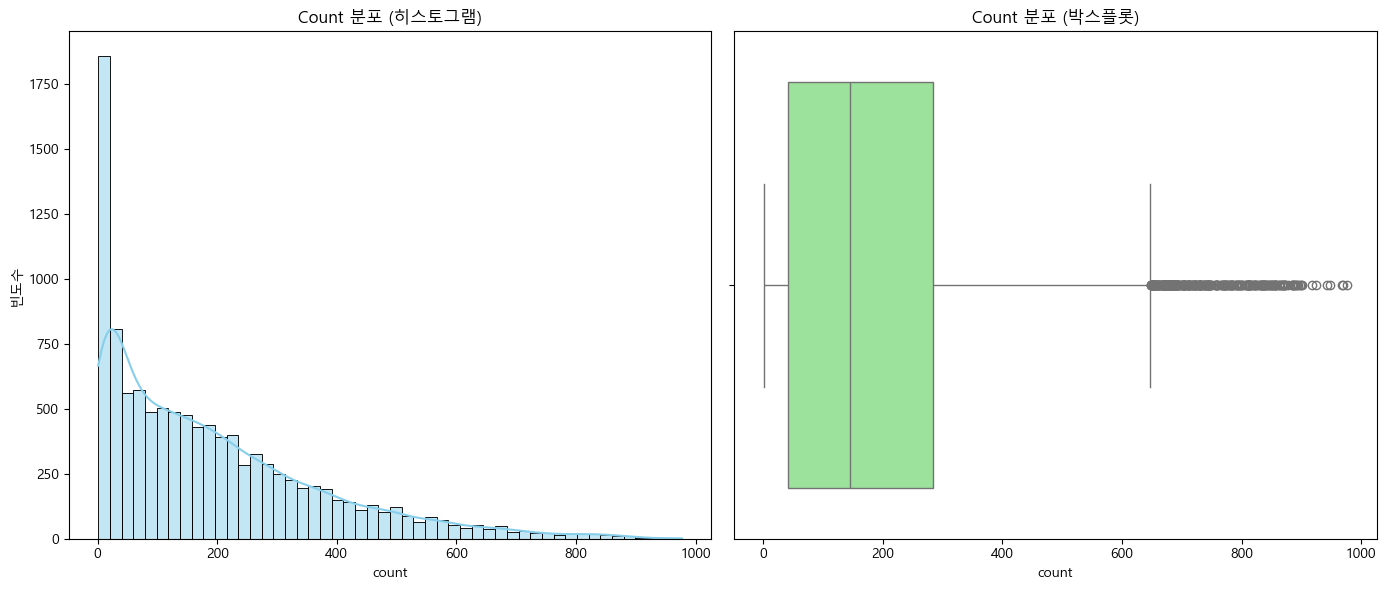

In [29]:
plt.figure(figsize=(14, 6))

# 히스토그램 - 분포 확인용
plt.subplot(1, 2, 1)
sns.histplot(y, bins=50, kde=True, color='skyblue')
plt.title('Count 분포 (히스토그램)')
plt.xlabel('count')
plt.ylabel('빈도수')

# 박스플롯 - 이상치 및 분포 범위 확인용
plt.subplot(1, 2, 2)
sns.boxplot(x=y, color='lightgreen')
plt.title('Count 분포 (박스플롯)')
plt.xlabel('count')

plt.tight_layout()
plt.show()


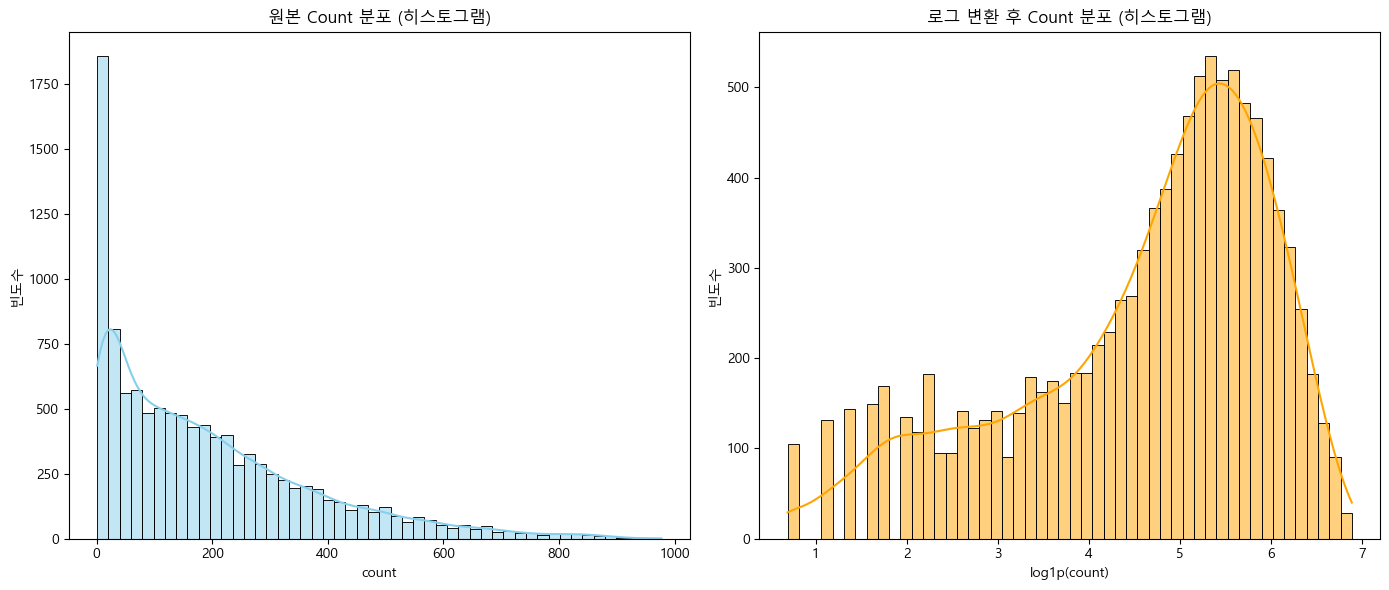

In [30]:
# 로그 변환
y_log = np.log1p(y)  # log(1 + y)

plt.figure(figsize=(14, 6))

# 원본 y 분포 (히스토그램)
plt.subplot(1, 2, 1)
sns.histplot(y, bins=50, kde=True, color='skyblue')
plt.title('원본 Count 분포 (히스토그램)')
plt.xlabel('count')
plt.ylabel('빈도수')

# 로그 변환 후 y 분포 (히스토그램)
plt.subplot(1, 2, 2)
sns.histplot(y_log, bins=50, kde=True, color='orange')
plt.title('로그 변환 후 Count 분포 (히스토그램)')
plt.xlabel('log1p(count)')
plt.ylabel('빈도수')

plt.tight_layout()
plt.show()


In [31]:
# X, y 복사 및 변환
X_train_copy = X_train.values.copy() if hasattr(X_train, 'values') else np.asarray(X_train).copy()
y_train_copy = y_train.values.copy() if hasattr(y_train, 'values') else np.asarray(y_train).copy()

In [32]:
# 타깃 로그 변환
y_train_log = np.log1p(y_train_copy)

In [33]:
# 모델 정의
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(),
    "GradientBoosting": GradientBoostingRegressor(),
    "XGBRegressor": XGBRegressor(),
    "LGBMRegressor": LGBMRegressor()
}

# KFold 설정
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# 모델별 교차검증
for name, model in models.items():
    # 로그 스케일에서 예측
    y_pred_log = cross_val_predict(model, X_train_copy, y_train_log, cv=cv, n_jobs=-1)
    
    # 역변환하여 실제 스케일로
    y_pred = np.expm1(y_pred_log)
    
    # 평가 지표
    mse = mean_squared_error(y_train_copy, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_train_copy, y_pred)

    print(f"{name} (로그 변환 교차검증 결과):")
    print(f"평균 MSE:  {mse:.4f}")
    print(f"평균 RMSE: {rmse:.4f}")
    print(f"평균 R2:   {r2:.4f}")
    print("-" * 40)

LinearRegression (로그 변환 교차검증 결과):
평균 MSE:  25897.2231
평균 RMSE: 160.9261
평균 R2:   0.2028
----------------------------------------
RandomForest (로그 변환 교차검증 결과):
평균 MSE:  1758.1667
평균 RMSE: 41.9305
평균 R2:   0.9459
----------------------------------------
GradientBoosting (로그 변환 교차검증 결과):
평균 MSE:  5174.8314
평균 RMSE: 71.9363
평균 R2:   0.8407
----------------------------------------
XGBRegressor (로그 변환 교차검증 결과):
평균 MSE:  1707.5428
평균 RMSE: 41.3224
평균 R2:   0.9474
----------------------------------------
LGBMRegressor (로그 변환 교차검증 결과):
평균 MSE:  1738.7231
평균 RMSE: 41.6980
평균 R2:   0.9465
----------------------------------------


In [34]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "XGBRegressor": XGBRegressor(random_state=42),
    "LGBMRegressor": LGBMRegressor(random_state=42)
}

for name, model in models.items():
    # 1) 로그 변환된 y로 전체 학습 데이터 학습
    model.fit(X_train_copy, y_train_log)
    
    # 2) 테스트셋 예측 (로그 스케일)
    y_pred_log = model.predict(X_test)
    
    # 3) 역변환하여 원래 스케일로 복원
    y_pred = np.expm1(y_pred_log)
    
    # 4) 평가 (실제 y_test와 비교)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # 5) RMSLE 계산 (실제값과 예측값 모두에 log1p 적용)
    rmsle = np.sqrt(mean_squared_error(np.log1p(y_test), np.log1p(y_pred)))
    
    print(f"{name} (전체 학습 후 테스트셋 평가):")
    print(f"  MSE:   {mse:.4f}")
    print(f"  RMSE:  {rmse:.4f}")
    print(f"  R2:    {r2:.4f}")
    print(f"  RMSLE: {rmsle:.4f}")
    print("-" * 40)

c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


LinearRegression (전체 학습 후 테스트셋 평가):
  MSE:   27171.8586
  RMSE:  164.8389
  R2:    0.2034
  RMSLE: 1.0261
----------------------------------------


c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


RandomForest (전체 학습 후 테스트셋 평가):
  MSE:   1840.6329
  RMSE:  42.9026
  R2:    0.9460
  RMSLE: 0.3061
----------------------------------------
GradientBoosting (전체 학습 후 테스트셋 평가):
  MSE:   5917.8722
  RMSE:  76.9277
  R2:    0.8265
  RMSLE: 0.3992
----------------------------------------
XGBRegressor (전체 학습 후 테스트셋 평가):
  MSE:   1747.2325
  RMSE:  41.7999
  R2:    0.9488
  RMSLE: 0.2949
----------------------------------------
LGBMRegressor (전체 학습 후 테스트셋 평가):
  MSE:   2047.2654
  RMSE:  45.2467
  R2:    0.9400
  RMSLE: 0.2976
----------------------------------------


c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(


In [35]:
# 하이퍼파라미터 후보
param_grid = {
    'num_leaves': [31, 50, 100],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300, 500],
    'max_depth': [5, 10, 20, -1]
}

lgbm = lgb.LGBMRegressor(random_state=42)

# 로그 변환된 타깃으로 CV 진행
grid = GridSearchCV(estimator=lgbm,
                    param_grid=param_grid,
                    cv=5,
                    scoring='neg_mean_squared_error',
                    n_jobs=-1,
                    verbose=2)

grid.fit(X_train_copy, y_train_log)

print("최적 하이퍼파라미터:", grid.best_params_)

# 최적 모델로 예측
best_model = grid.best_estimator_
y_pred_log = best_model.predict(X_train_copy)
y_pred = np.expm1(y_pred_log) # 예측 후 로그 역변환

# 평가
rmse = np.sqrt(mean_squared_error(y_train_copy, y_pred))
r2 = r2_score(y_train_copy, y_pred)
rmsle = np.sqrt(mean_squared_log_error(y_train_copy, y_pred))

print(f"Tuned LGBM Train 결과: RMSE={rmse:.4f}, R2={r2:.4f}, RMSLE={rmsle:.4f}")


Fitting 5 folds for each of 108 candidates, totalling 540 fits
최적 하이퍼파라미터: {'learning_rate': 0.05, 'max_depth': 20, 'n_estimators': 500, 'num_leaves': 50}
Tuned LGBM Train 결과: RMSE=27.4502, R2=0.9768, RMSLE=0.1821


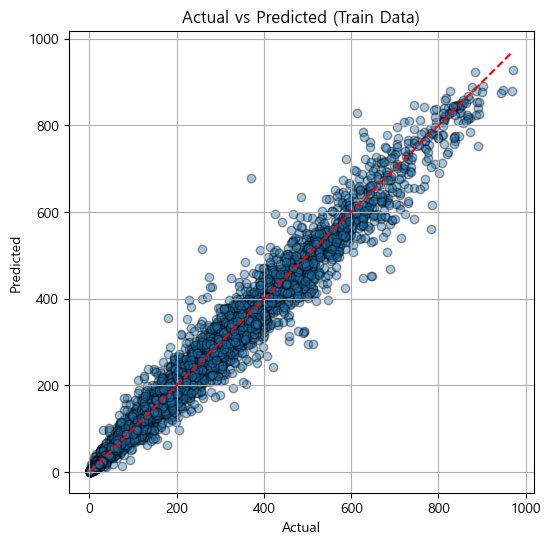

In [36]:
# 실제값 vs 예측값 산점도

# 예측값 (로그 변환 후 역변환)
y_pred_log = best_model.predict(X_train_copy)
y_pred = np.expm1(y_pred_log)

plt.figure(figsize=(6,6))
plt.scatter(y_train_copy, y_pred, alpha=0.4, edgecolor='k')
plt.plot([y_train_copy.min(), y_train_copy.max()], [y_train_copy.min(), y_train_copy.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Train Data)")
plt.grid(True)
plt.show()


In [37]:
# 오차 분포 히스토그램 - 오차가 정규분포에 가까우면 모델 예측이 안정적

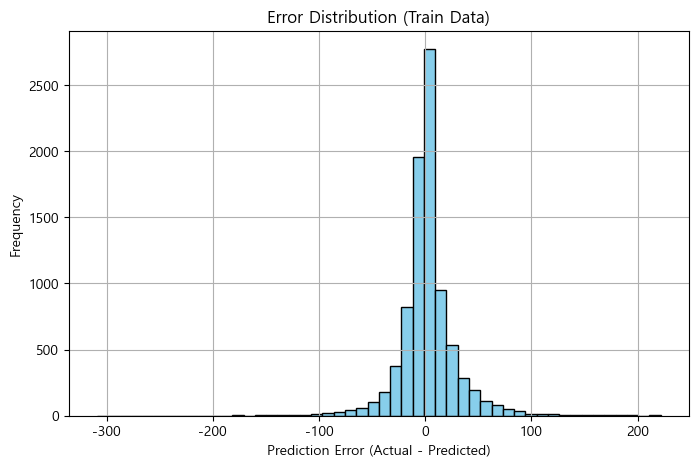

In [38]:
errors = y_train_copy - y_pred

plt.figure(figsize=(8,5))
plt.hist(errors, bins=50, color='skyblue', edgecolor='black')
plt.xlabel("Prediction Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Error Distribution (Train Data)")
plt.grid(True)
plt.show()


In [39]:
# 하이퍼파라미터 최소 탐색 범위 설정
param_grid_minimal = {
    'learning_rate': [0.04, 0.05, 0.06],
    'max_depth': [14, 15, 16],
    'num_leaves': [45, 50, 55],
    'n_estimators': [550, 600, 650]
}

lgbm = lgb.LGBMRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid_minimal,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# 로그 변환된 y로 학습
grid_search.fit(X_train_copy, y_train_log)

# 결과 출력
best_params = grid_search.best_params_
best_rmse = np.sqrt(-grid_search.best_score_)

print("최적 하이퍼파라미터:", best_params)
print("최고 CV RMSE:", round(best_rmse, 4))

# 최적 모델로 훈련셋 예측
best_model = grid_search.best_estimator_
y_pred_log = best_model.predict(X_train_copy)
y_pred = np.expm1(y_pred_log)

rmse = np.sqrt(mean_squared_error(y_train_copy, y_pred))
r2 = r2_score(y_train_copy, y_pred)
rmsle = np.sqrt(mean_squared_log_error(y_train_copy, y_pred))

print(f"Tuned LGBM Train 결과: RMSE={rmse:.4f}, R2={r2:.4f}, RMSLE={rmsle:.4f}")


Fitting 5 folds for each of 81 candidates, totalling 405 fits
최적 하이퍼파라미터: {'learning_rate': 0.05, 'max_depth': 16, 'n_estimators': 550, 'num_leaves': 45}
최고 CV RMSE: 0.2803
Tuned LGBM Train 결과: RMSE=27.0860, R2=0.9774, RMSLE=0.1830


In [40]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error
import lightgbm as lgb
import numpy as np

# 하이퍼파라미터 그리드
param_grid_fine = {
    'learning_rate': [0.03, 0.04, 0.05, 0.06, 0.07],
    'max_depth': [12, 13, 14, 15, 16, 17],
    'num_leaves': [40, 45, 50, 55, 60],
    'n_estimators': [550, 600, 650],
    'min_child_samples': [10, 20, 30],
    'feature_fraction': [0.7, 0.8, 0.9],
    'bagging_fraction': [0.7, 0.8, 0.9],
    'bagging_freq': [1, 5]
}

# 모델 정의
lgbm = lgb.LGBMRegressor(random_state=42)

# RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid_fine,
    n_iter=200,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# 학습 (로그변환된 y 사용)
search.fit(X_train_copy, y_train_log)

# 최적 하이퍼파라미터 출력
print("최적 하이퍼파라미터:", search.best_params_)
print("최고 CV 점수 (neg_mean_squared_error):", search.best_score_)
print("최고 CV RMSE:", np.sqrt(-search.best_score_))

# 최적 모델로 전체 학습셋 예측
best_model = search.best_estimator_
y_pred_log = best_model.predict(X_train_copy)
y_pred = np.expm1(y_pred_log)

# 로그 되돌린 실제값으로 평가
y_true = y_train_copy  # 로그변환 전의 y

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred))

print(f"\nTuned LGBM Train 결과:")
print(f"RMSE = {rmse:.4f}")
print(f"R2   = {r2:.4f}")
print(f"RMSLE= {rmsle:.4f}")


Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
최적 하이퍼파라미터: {'num_leaves': 50, 'n_estimators': 650, 'min_child_samples': 10, 'max_depth': 14, 'learning_rate': 0.03, 'feature_fraction': 0.9, 'bagging_freq': 5, 'bagging_fraction': 0.9}
최고 CV 점수 (neg_mean_squared_error): -0.07707352997655914
최고 CV RMSE: 0.27762119871609076

Tuned LGBM Train 결과:
RMSE = 28.7670
R2   = 0.9745
RMSLE= 0.1820


# 로그 변환 vs 미변환 모델 비교

In [41]:
# 1. 로그 변환된 타깃 변수
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# 2. 모델 생성
rf_log = RandomForestRegressor(random_state=42)
rf_raw = RandomForestRegressor(random_state=42)

# 3. 모델 학습
rf_log.fit(X_train, y_train_log)
rf_raw.fit(X_train, y_train)

# 4. 예측
y_pred_log = np.expm1(rf_log.predict(X_test))  # 역변환
y_pred_raw = rf_raw.predict(X_test)

# 5. 평가 지표 계산
mse_log = mean_squared_error(y_test, y_pred_log)
rmse_log = np.sqrt(mse_log)
r2_log = r2_score(y_test, y_pred_log)

mse_raw = mean_squared_error(y_test, y_pred_raw)
rmse_raw = np.sqrt(mse_raw)
r2_raw = r2_score(y_test, y_pred_raw)

# 6. 결과 정리
results = pd.DataFrame({
    "모델": ["로그 변환", "미변환"],
    "MSE": [mse_log, mse_raw],
    "RMSE": [rmse_log, rmse_raw],
    "R²": [r2_log, r2_raw]
})

print(results)


      모델          MSE       RMSE        R²
0  로그 변환  1840.632932  42.902598  0.946040
1    미변환  1789.223586  42.299215  0.947547


c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


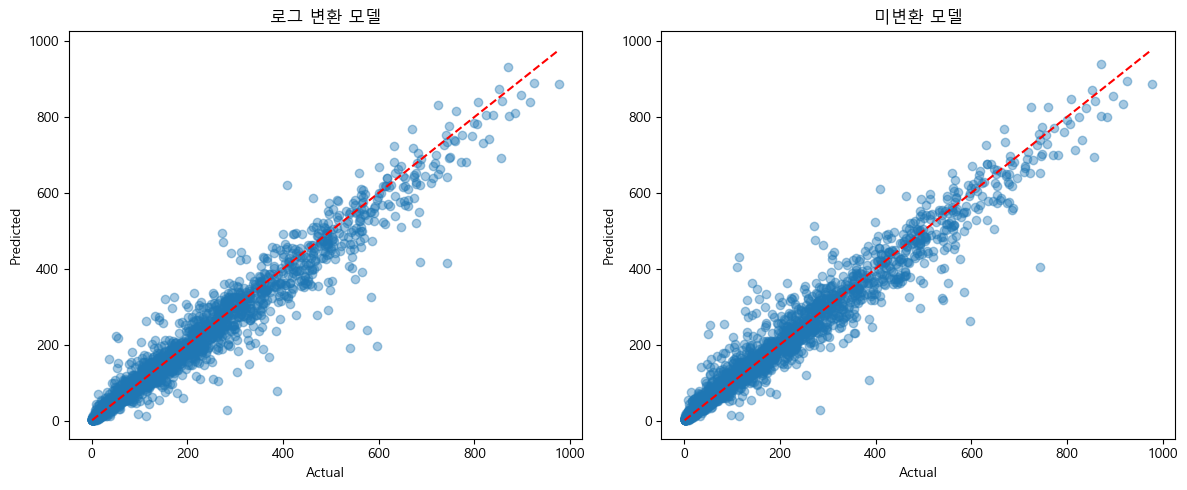

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_log, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("로그 변환 모델")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_raw, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("미변환 모델")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.tight_layout()
plt.show()
